# Наивный Баесовский классификатор

In [63]:
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from scipy.stats import norm
import numpy as np

In [44]:
file = 'author_ru_utf.csv'
df = pd.read_csv(file, sep = ',', header = 0)
df = df.loc[:, 'document':'Author']
df.head()

,document,на,что,за,и,в,из,со,а,во,...,о,ко,над,без,при,об,через,из-за,из-под,Author
0,ГогольНВ_ВечераЧ1_1.txt,154,95,42,309,157,40,8,46,10,...,5,1,6,10,5,4,1,0,0,ГогольНВ
1,ГогольНВ_ВечераЧ1_2.txt,179,158,71,413,233,40,8,53,7,...,15,2,4,8,11,7,5,1,0,ГогольНВ
2,ГогольНВ_ВечераЧ1_3.txt,164,140,52,363,214,29,4,49,8,...,10,3,5,4,12,4,6,1,1,ГогольНВ
3,ГогольНВ_ВечераЧ2_1.txt,172,160,42,370,211,50,7,60,10,...,9,3,6,12,11,10,4,0,0,ГогольНВ
4,ГогольНВ_ВечераЧ2_2.txt,171,129,43,331,183,41,7,67,8,...,13,3,8,12,6,3,7,5,1,ГогольНВ


In [61]:
# Приготовить данные
X = df.loc[:, 'на' : 'из-под']
Y = df['Author']
Y.head()

0    ГогольНВ
1    ГогольНВ
2    ГогольНВ
3    ГогольНВ
4    ГогольНВ
Name: Author, dtype: object

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = MultinomialNB()

model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [67]:
y_pred = model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Подсчитать 
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8586956521739131
               precision    recall  f1-score   support

     ГогольНВ       0.62      0.91      0.74        11
   ГончаровИА       0.89      1.00      0.94        17
ДостоевскийФМ       0.91      0.86      0.89        37
    ТолстойЛН       0.91      0.74      0.82        27

     accuracy                           0.86        92
    macro avg       0.84      0.88      0.85        92
 weighted avg       0.87      0.86      0.86        92



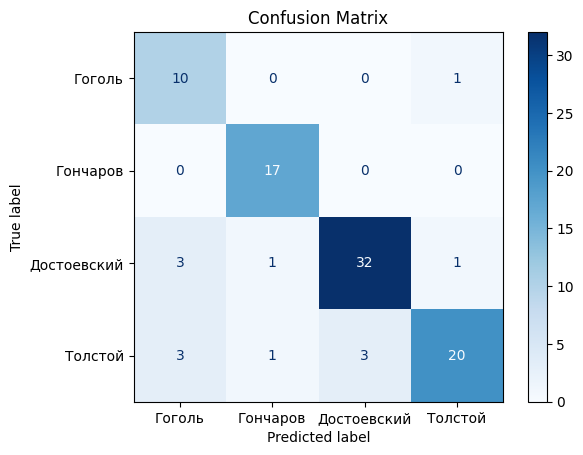

In [72]:
cm = confusion_matrix(y_test, y_pred)

# 6. Plot the confusion matrix using ConfusionMatrixDisplay
# You can customize labels and other plot parameters
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Гоголь', 'Гончаров', 'Достоевский', 'Толстой'])
disp.plot(cmap=plt.cm.Blues) # Choose a colormap
plt.title('Confusion Matrix')
plt.show()